# Домашнее задание по теме «Рекомендации на основе содержания»

## 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 4)

In [2]:
ratings = pd.read_csv(f'data/ratings.csv')
movies = pd.read_csv(f'data/movies.csv')
tags = pd.read_csv(f'data/tags.csv')

print('ratings:', ratings.shape, '| movies:', movies.shape, '| tags:', tags.shape)
print('пользователей:', ratings.userId.nunique(), '| фильмов с оценками:', ratings.movieId.nunique())
ratings.head()

ratings: (100836, 4) | movies: (9742, 3) | tags: (3683, 4)
пользователей: 610 | фильмов с оценками: 9724


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Пропуски: 0 0 0


,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


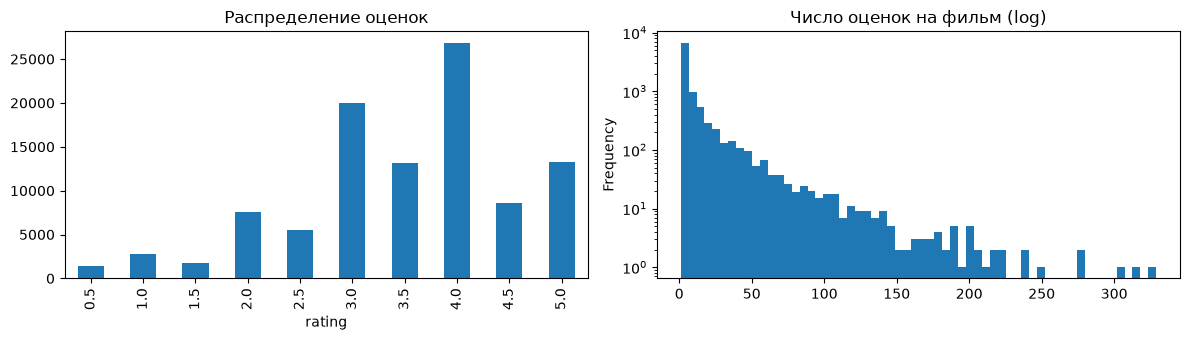

In [3]:
print('Пропуски:', ratings.isnull().sum().sum(), movies.isnull().sum().sum(), tags.isnull().sum().sum())
display(ratings['rating'].describe().to_frame().T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ratings['rating'].value_counts().sort_index().plot.bar(ax=ax[0], title='Распределение оценок')
ratings.groupby('movieId').size().plot.hist(bins=60, log=True, ax=ax[1], title='Число оценок на фильм (log)')
plt.tight_layout()
plt.show()

## 2. Контентные признаки: TF-IDF на жанрах и тегах

Жанры лежат в `movies.csv` строкой вида `Adventure|Animation|Children`, теги - в `tags.csv`
Собираем для каждого фильма два текстовых поля и считаем по ним TF-IDF:

* `genres_txt` - жанры (словарь маленький, ~20 токенов)
* `tags_txt` - конкатенация всех тегов фильма (`min_df=2`, униграммы + биграммы).

Дополнительно из названия вытаскиваем год выпуска.

In [4]:
movies['genres_txt'] = (movies['genres']
                        .str.replace('(no genres listed)', '', regex=False)
                        .str.replace('|', ' ', regex=False)
                        .str.replace('-', '', regex=False)
                        .str.lower())

tags_agg = (tags.assign(tag=tags['tag'].astype(str).str.lower())
                .groupby('movieId')['tag']
                .apply(' '.join)
                .rename('tags_txt'))

movies = movies.merge(tags_agg, on='movieId', how='left')
movies['tags_txt'] = movies['tags_txt'].fillna('')
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)\s*$').astype(float)

print('Фильмов с тегами:', (movies['tags_txt'] != '').sum(), 'из', len(movies))
movies[['movieId', 'title', 'genres_txt', 'tags_txt', 'year']].head()

Фильмов с тегами: 1572 из 9742


,movieId,title,genres_txt,tags_txt,year
0,1,Toy Story (1995),adventure animation children comedy fantasy,pixar pixar fun,1995.0
1,2,Jumanji (1995),adventure children fantasy,fantasy magic board game robin williams game,1995.0
2,3,Grumpier Old Men (1995),comedy romance,moldy old,1995.0
3,4,Waiting to Exhale (1995),comedy drama romance,,1995.0
4,5,Father of the Bride Part II (1995),comedy,pregnancy remake,1995.0


In [5]:
tfidf_genres = TfidfVectorizer(token_pattern=r'[^ ]+')
X_genres = tfidf_genres.fit_transform(movies['genres_txt'])

tfidf_tags = TfidfVectorizer(min_df=2, max_features=3000, ngram_range=(1, 2), sublinear_tf=True)
X_tags = tfidf_tags.fit_transform(movies['tags_txt'])

X_content = sparse.hstack([X_genres, X_tags]).tocsr()

print('TF-IDF жанры:', X_genres.shape, '| TF-IDF теги:', X_tags.shape, '| вместе:', X_content.shape)
print('\nЖанры:', tfidf_genres.get_feature_names_out())
print('\nПримеры тегов:', list(tfidf_tags.get_feature_names_out()[:15]))

TF-IDF жанры: (9742, 19) | TF-IDF теги: (9742, 1119) | вместе: (9742, 1138)

Жанры: ['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'filmnoir' 'horror' 'imax' 'musical'
 'mystery' 'romance' 'scifi' 'thriller' 'war' 'western']

Примеры тегов: ['06', '06 oscar', '1920s', '1950s', '1970s', '1980s', '250', '250 james', 'aardman', 'abuse', 'acting', 'acting bad', 'action', 'action action', 'actress']


Разреженная матрица из 1138 столбцов подходит для линейной модели, но для градиентного бустинга
её лучше сжать. Берём `TruncatedSVD` (LSA) до 60 компонент.

In [6]:
svd = TruncatedSVD(n_components=60, random_state=RANDOM_STATE)
Z_content = svd.fit_transform(X_content)

print('Форма:', Z_content.shape)
print(f'Объяснённая дисперсия 60 компонентами: {svd.explained_variance_ratio_.sum():.3f}')

movie_row = pd.Series(np.arange(len(movies)), index=movies['movieId'])

Форма: (9742, 60)
Объяснённая дисперсия 60 компонентами: 0.898


## 3. Разбиение на train / valid / test

Разбиваем сами оценки: 20 % на тест, из оставшегося 10 % на валидацию.

In [7]:
train_full, test = train_test_split(ratings, test_size=0.2, random_state=RANDOM_STATE)
train, valid = train_test_split(train_full, test_size=0.1, random_state=RANDOM_STATE)
GLOBAL_MEAN = train['rating'].mean()

print('train:', train.shape, '| valid:', valid.shape, '| test:', test.shape)
print(f'Средняя оценка на train: {GLOBAL_MEAN:.4f}')
print('Холодных фильмов в тесте (нет в train):',
      (~test['movieId'].isin(train['movieId'])).sum())
print('Холодных пользователей в тесте:',
      (~test['userId'].isin(train['userId'])).sum())

train: (72601, 4) | valid: (8067, 4) | test: (20168, 4)
Средняя оценка на train: 3.5024
Холодных фильмов в тесте (нет в train): 874
Холодных пользователей в тесте: 0


## 4. Статистики пользователя и фильма

Для пользователя и для фильма считаем по train: `mean`, `median`, `std`, `var`, `count`, `min`, `max`

Отдельно, смещения, которые обычно дают основной вклад:

* `u_bias` - насколько пользователь в среднем оценивает выше/ниже средней оценки фильмов, которые он смотрел
* `m_bias` - насколько фильм в среднем оценивают выше/ниже, чем в среднем оценивают эти пользователи
* `baseline = μ + u_bias + m_bias` - классический baseline-предиктор из рекомендательных систем

In [8]:
def aggregate(df, key, prefix):
    g = df.groupby(key)['rating']
    return pd.DataFrame({
        f'{prefix}_mean':   g.mean(),
        f'{prefix}_median': g.median(),
        f'{prefix}_std':    g.std(),
        f'{prefix}_var':    g.var(),
        f'{prefix}_cnt':    g.count(),
        f'{prefix}_min':    g.min(),
        f'{prefix}_max':    g.max(),
    })


user_stats = aggregate(train, 'userId', 'u')
movie_stats = aggregate(train, 'movieId', 'm')

tr = (train.merge(movie_stats[['m_mean']], on='movieId', how='left')
           .merge(user_stats[['u_mean']], on='userId', how='left'))
user_stats = user_stats.join((tr['rating'] - tr['m_mean']).groupby(tr['userId']).mean().rename('u_bias'))
movie_stats = movie_stats.join((tr['rating'] - tr['u_mean']).groupby(tr['movieId']).mean().rename('m_bias'))

display(user_stats.head())
display(movie_stats.head())

,u_mean,u_median,u_std,u_var,u_cnt,u_min,u_max,u_bias
userId,,,,,,,,
1,4.319767,5.00,0.828628,0.686625,172,1.0,5.0,0.730667
2,3.886364,4.00,0.858179,0.736472,22,2.0,5.0,-0.023336
3,2.500000,1.25,2.113177,4.465517,30,0.5,5.0,-1.237190
4,3.462025,4.00,1.385255,1.918931,158,1.0,5.0,-0.284070
5,3.666667,4.00,1.069045,1.142857,36,1.0,5.0,-0.035739


,m_mean,m_median,m_std,m_var,m_cnt,m_min,m_max,m_bias
movieId,,,,,,,,
1,3.867742,4.0,0.825875,0.682070,155,0.5,5.0,0.270812
2,3.371795,3.5,0.927347,0.859973,78,0.5,5.0,-0.119057
3,3.148649,3.0,1.046587,1.095345,37,0.5,5.0,-0.308777
4,2.100000,2.0,0.894427,0.800000,5,1.0,3.0,-1.110614
5,2.984375,3.0,0.979503,0.959425,32,0.5,5.0,-0.644075


### Контентный профиль пользователя

Построим профиль пользователя как средневзвешенную сумму L2-нормированных TF-IDF-векторов фильмов, которые он оценил в train.
Скалярное произведение профиля и вектора фильма (`content_match`) показывает, насколько фильм
похож по жанрам/тегам на то, что пользователю раньше 'нравилось'.

In [9]:
X_norm = sparse.csr_matrix(X_content.multiply(
    1 / (np.sqrt(X_content.multiply(X_content).sum(axis=1)) + 1e-9)))

rows = movie_row.reindex(train['movieId']).values
user_codes, user_index = pd.factorize(train['userId'])
weights = train['rating'].values - GLOBAL_MEAN

W = sparse.csr_matrix((weights, (user_codes, rows)), shape=(len(user_index), len(movies)))
n_rated = np.bincount(user_codes, minlength=len(user_index))
user_profile = sparse.csr_matrix((W @ X_norm) / np.maximum(n_rated, 1)[:, None])
profile_row = pd.Series(np.arange(len(user_index)), index=user_index)

print('Профили пользователей:', user_profile.shape)


def content_match(df):
    """Скалярное произведение профиля пользователя и контентного вектора фильма."""
    ur = profile_row.reindex(df['userId']).values
    mr = movie_row.reindex(df['movieId']).values
    known = ~np.isnan(ur) & ~np.isnan(mr)
    out = np.zeros(len(df))
    out[known] = np.asarray(
        user_profile[ur[known].astype(int)].multiply(X_norm[mr[known].astype(int)]).sum(axis=1)).ravel()
    return out

Профили пользователей: (610, 1138)


## 5. Сборка матрицы признаков

Для холодных пользователей/фильмов средние заполняем глобальным средним, смещения - нулём.

In [10]:
def build_features(df):
    d = (df.merge(user_stats, on='userId', how='left')
           .merge(movie_stats, on='movieId', how='left')
           .merge(movies[['movieId', 'year']], on='movieId', how='left'))

    d['u_bias'] = d['u_bias'].fillna(0.0)
    d['m_bias'] = d['m_bias'].fillna(0.0)
    d['baseline'] = GLOBAL_MEAN + d['u_bias'] + d['m_bias']
    d['mean_diff'] = d['u_mean'].fillna(GLOBAL_MEAN) - d['m_mean'].fillna(GLOBAL_MEAN)
    d['cnt_ratio'] = np.log1p(d['u_cnt'].fillna(0)) - np.log1p(d['m_cnt'].fillna(0))
    d['content_match'] = content_match(df)
    d['rating_age'] = pd.to_datetime(df['timestamp'].values, unit='s').year - d['year']

    for c in ['u_mean', 'm_mean', 'u_median', 'm_median']:
        d[c] = d[c].fillna(GLOBAL_MEAN)
    d = d.fillna(0.0)

    num = d.select_dtypes(include='number')
    feature_cols = [c for c in num.columns if c not in ('userId', 'movieId', 'rating', 'timestamp')]
    return num[feature_cols]


F_train = build_features(train)
F_valid = build_features(valid)
F_test = build_features(test)
y_train, y_valid, y_test = train['rating'].values, valid['rating'].values, test['rating'].values

rows_train = movie_row.reindex(train['movieId']).values.astype(int)
rows_valid = movie_row.reindex(valid['movieId']).values.astype(int)
rows_test = movie_row.reindex(test['movieId']).values.astype(int)

print('Табличных признаков:', F_train.shape[1])
print(list(F_train.columns))
F_train.head()

Табличных признаков: 22
['u_mean', 'u_median', 'u_std', 'u_var', 'u_cnt', 'u_min', 'u_max', 'u_bias', 'm_mean', 'm_median', 'm_std', 'm_var', 'm_cnt', 'm_min', 'm_max', 'm_bias', 'year', 'baseline', 'mean_diff', 'cnt_ratio', 'content_match', 'rating_age']


,u_mean,u_median,u_std,u_var,u_cnt,u_min,u_max,u_bias,m_mean,m_median,m_std,m_var,m_cnt,m_min,m_max,m_bias,year,baseline,mean_diff,cnt_ratio,content_match,rating_age
0,3.678457,3.5,0.856080,0.732872,933,0.5,5.0,0.206433,3.750000,3.75,0.353553,0.125000,2,3.5,4.0,0.589962,1966.0,4.298750,-0.071543,5.740864,0.055043,50.0
1,2.980374,3.0,1.066202,1.136786,535,0.5,5.0,-0.391296,3.772727,4.00,0.886202,0.785354,55,0.5,5.0,0.336329,1964.0,3.447388,-0.792353,2.258782,-0.060989,45.0
2,3.255418,3.5,0.767384,0.588878,969,0.5,5.0,-0.006192,4.166667,4.00,0.683130,0.466667,6,3.5,5.0,0.714179,1986.0,4.210342,-0.911249,4.931386,-0.062022,21.0
3,4.125000,4.0,0.740683,0.548611,28,2.0,5.0,0.428884,4.154930,4.50,0.881615,0.777245,142,0.5,5.0,0.452337,2001.0,4.383576,-0.029930,-1.595549,0.061239,6.0
4,3.634146,4.0,1.066679,1.137805,41,1.0,5.0,0.156708,3.810606,4.00,1.044271,1.090501,66,1.0,5.0,0.159058,1998.0,3.818122,-0.176460,-0.467023,0.026080,2.0


In [11]:
scaler = StandardScaler().fit(F_train.values)
S_train = scaler.transform(F_train.values)
S_valid = scaler.transform(F_valid.values)
S_test = scaler.transform(F_test.values)


def rmse(y_true, y_pred):
    """RMSE с обрезкой предсказаний в допустимый диапазон оценок [0.5, 5]."""
    return float(np.sqrt(mean_squared_error(y_true, np.clip(y_pred, 0.5, 5.0))))


results = {}

## 6. Бейзлайны

Чтобы понимать, что даёт модель, сравниваем с простыми предсказаниями.

In [12]:
results['Глобальное среднее'] = rmse(y_test, np.full(len(y_test), GLOBAL_MEAN))
results['Среднее по фильму'] = rmse(y_test, F_test['m_mean'].values)
results['Среднее по пользователю'] = rmse(y_test, F_test['u_mean'].values)
results['Baseline: μ + u_bias + m_bias'] = rmse(y_test, F_test['baseline'].values)

for k, v in results.items():
    print(f'{k:32s} RMSE = {v:.4f}')

Глобальное среднее               RMSE = 1.0488
Среднее по фильму                RMSE = 0.9881
Среднее по пользователю          RMSE = 0.9502
Baseline: μ + u_bias + m_bias    RMSE = 0.9019


## 7. Модель 1: Ridge на разреженных признаках

Линейная регрессия по объединению [масштабированные статистики | полная TF-IDF-матрица фильма].

In [13]:
A_train = sparse.hstack([sparse.csr_matrix(S_train), X_content[rows_train]]).tocsr()
A_valid = sparse.hstack([sparse.csr_matrix(S_valid), X_content[rows_valid]]).tocsr()
A_test = sparse.hstack([sparse.csr_matrix(S_test), X_content[rows_test]]).tocsr()
print('Размер разреженной матрицы:', A_train.shape)

# alpha подбираем по валидации
for alpha in [0.3, 1.0, 3.0, 10.0]:
    r = Ridge(alpha=alpha).fit(A_train, y_train)
    print(f'alpha={alpha:5.1f}  RMSE(valid) = {rmse(y_valid, r.predict(A_valid)):.4f}')

Размер разреженной матрицы: (72601, 1160)
alpha=  0.3  RMSE(valid) = 0.8643
alpha=  1.0  RMSE(valid) = 0.8643
alpha=  3.0  RMSE(valid) = 0.8644
alpha= 10.0  RMSE(valid) = 0.8644


In [14]:
ridge = Ridge(alpha=1.0).fit(A_train, y_train)
val_ridge = np.clip(ridge.predict(A_valid), 0.5, 5.0)
pred_ridge = np.clip(ridge.predict(A_test), 0.5, 5.0)
results['Ridge (статистики + TF-IDF)'] = rmse(y_test, pred_ridge)
print('Ridge RMSE =', round(results['Ridge (статистики + TF-IDF)'], 4))

Ridge RMSE = 0.8936


## 8. Модель 2: градиентный бустинг на статистиках + SVD-эмбеддингах

`HistGradientBoostingRegressor` - быстрый бустинг из sklearn. На вход: те же табличные признаки
плюс 60 SVD-компонент контента.

In [15]:
D_train = np.hstack([S_train, Z_content[rows_train]])
D_valid = np.hstack([S_valid, Z_content[rows_valid]])
D_test = np.hstack([S_test, Z_content[rows_test]])

hgb = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.06, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE
).fit(D_train, y_train)

val_hgb = np.clip(hgb.predict(D_valid), 0.5, 5.0)
pred_hgb = np.clip(hgb.predict(D_test), 0.5, 5.0)
results['HistGradientBoosting (статистики + SVD)'] = rmse(y_test, pred_hgb)
print('Итераций:', hgb.n_iter_)
print('HGB RMSE =', round(results['HistGradientBoosting (статистики + SVD)'], 4))

Итераций: 335
HGB RMSE = 0.8814


In [16]:
hgb_stats = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.06, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE
).fit(S_train, y_train)

results['HGB только на статистиках'] = rmse(y_test, hgb_stats.predict(S_test))
print('HGB без TF-IDF: RMSE =', round(results['HGB только на статистиках'], 4))

HGB без TF-IDF: RMSE = 0.8822


## 9. Блендинг

Линейные и деревянные модели ошибаются по-разному, взвешенное усреднение немного улучшит результат.

In [17]:
best_w, best_val = None, np.inf
for w in np.arange(0, 1.01, 0.1):
    s = rmse(y_valid, w * val_ridge + (1 - w) * val_hgb)
    if s < best_val:
        best_w, best_val = w, s
    print(f'w(Ridge)={w:.1f}  RMSE(valid) = {s:.4f}')

print(f'\nЛучший вес Ridge по валидации: {best_w:.1f} (RMSE valid = {best_val:.4f})')

blend_test = rmse(y_test, best_w * pred_ridge + (1 - best_w) * pred_hgb)
results[f'Блендинг {best_w:.1f}·Ridge + {1 - best_w:.1f}·HGB'] = blend_test
print(f'RMSE на тесте: {blend_test:.4f}')

w(Ridge)=0.0  RMSE(valid) = 0.8565
w(Ridge)=0.1  RMSE(valid) = 0.8544
w(Ridge)=0.2  RMSE(valid) = 0.8528
w(Ridge)=0.3  RMSE(valid) = 0.8520
w(Ridge)=0.4  RMSE(valid) = 0.8518
w(Ridge)=0.5  RMSE(valid) = 0.8522
w(Ridge)=0.6  RMSE(valid) = 0.8534
w(Ridge)=0.7  RMSE(valid) = 0.8551
w(Ridge)=0.8  RMSE(valid) = 0.8576
w(Ridge)=0.9  RMSE(valid) = 0.8606
w(Ridge)=1.0  RMSE(valid) = 0.8643

Лучший вес Ridge по валидации: 0.4 (RMSE valid = 0.8518)
RMSE на тесте: 0.8783


## 10. Важность признаков

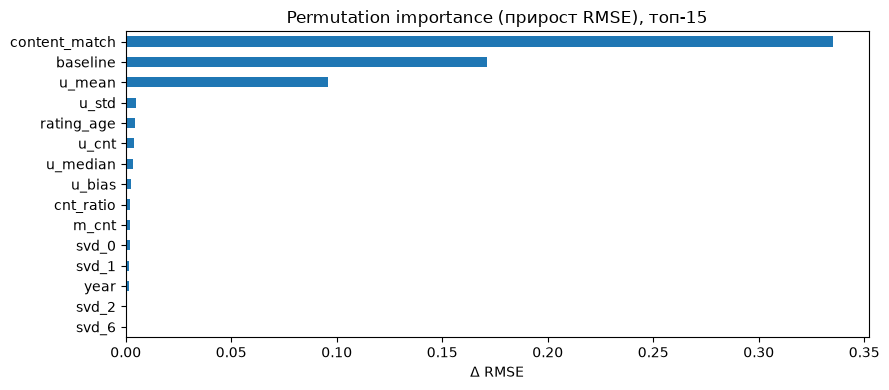

Суммарный вклад SVD-компонент контента: 0.00758


In [18]:
perm = permutation_importance(hgb, D_test, y_test, n_repeats=5,
                              random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error')

names = list(F_train.columns) + [f'svd_{i}' for i in range(Z_content.shape[1])]
imp = pd.Series(perm.importances_mean, index=names).sort_values(ascending=False)

imp.head(15)[::-1].plot.barh(title='Permutation importance (прирост RMSE), топ-15')
plt.xlabel('Δ RMSE')
plt.tight_layout()
plt.show()

print('Суммарный вклад SVD-компонент контента:',
      round(imp[[n for n in names if n.startswith("svd_")]].sum(), 5))

## 11. Итоговое сравнение и RMSE на тесте

,RMSE (test)
Глобальное среднее,1.0488
Среднее по фильму,0.9881
Среднее по пользователю,0.9502
Baseline: μ + u_bias + m_bias,0.9019
Ridge (статистики + TF-IDF),0.8936
HGB только на статистиках,0.8822
HistGradientBoosting (статистики + SVD),0.8814
Блендинг 0.4·Ridge + 0.6·HGB,0.8783


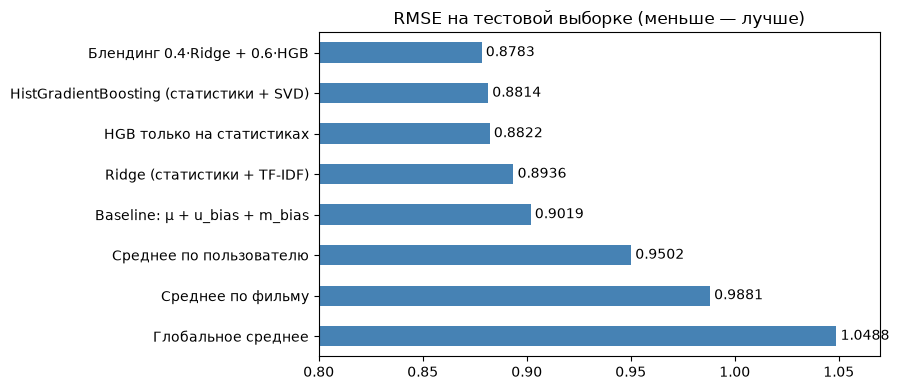

Лучшая модель: Блендинг 0.4·Ridge + 0.6·HGB - RMSE = 0.8783


In [19]:
scores = pd.Series(results).sort_values(ascending=False)
display(scores.to_frame('RMSE (test)').round(4))

ax = scores.plot.barh(title='RMSE на тестовой выборке (меньше — лучше)', color='steelblue')
ax.set_xlim(0.8, scores.max() * 1.02)
for i, v in enumerate(scores.values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

print(f'Лучшая модель: {scores.idxmin()} - RMSE = {scores.min():.4f}')

In [20]:
def recommend(user_id, top_n=10):
    seen = set(train.loc[train.userId == user_id, 'movieId'])
    cand = movies.loc[~movies['movieId'].isin(seen), ['movieId', 'title', 'genres']].copy()
    cand.insert(0, 'userId', user_id)
    cand['timestamp'] = train['timestamp'].max()

    Fc = build_features(cand)[F_train.columns]
    Dc = np.hstack([scaler.transform(Fc.values),
                    Z_content[movie_row.reindex(cand['movieId']).values.astype(int)]])
    cand['pred'] = np.clip(hgb.predict(Dc), 0.5, 5.0)
    return (cand.sort_values('pred', ascending=False)
                .head(top_n)[['title', 'genres', 'pred']]
                .reset_index(drop=True))


uid = 414
print(f'Пользователь {uid}: оценок в train = {(train.userId == uid).sum()}, '
      f'средняя = {train.loc[train.userId == uid, "rating"].mean():.2f}')
recommend(uid)

Пользователь 414: оценок в train = 1897, средняя = 3.40


,title,genres,pred
0,Lady Jane (1986),Drama|Romance,4.900342
1,Shogun Assassin (1980),Action|Adventure,4.898022
2,Into the Woods (1991),Adventure|Comedy|Fantasy|Musical,4.875859
3,Come and See (Idi i smotri) (1985),Drama|War,4.871115
4,Holy Motors (2012),Drama|Fantasy|Musical|Mystery|Sci-Fi,4.865718
5,Gigantic (A Tale of Two Johns) (2002),Documentary,4.860471
6,Delirium (2014),Adventure|Romance|Sci-Fi,4.858850
7,Tokyo Tribe (2014),Action|Crime|Drama|Sci-Fi,4.852186
8,More (1998),Animation|Drama|Sci-Fi|IMAX,4.851508
9,Lamerica (1994),Adventure|Drama,4.847035


## Выводы
Основной вклад вносят агрегаты пользователя и фильма (в первую очередь `baseline`, `m_mean`, `u_mean`). Контентные признаки на этом объёме данных дают небольшой прирост (0.8822 → 0.8814 у бустинга) и, что важнее для рекомендательной системы, позволяют
предсказывать оценку для фильмов с малым числом оценок, где средние ненадёжны: в тесте 874 оценки относятся к фильмам, которых вообще нет в train, и для них работают только контентные признаки и статистики пользователя.